In [5]:
# =============================================================================
# Zelle 01 – Setup & Datenladen (EDA Modell B)
# =============================================================================
import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from viz_config_v2 import apply_store44_style, save_figure, COLOR_GOLD, COLOR_BLUE, COLOR_GREEN, COLOR_TEXT_MUTED, BOXPLOT_STYLE

SEED = 42
apply_store44_style()

df_b = pd.read_csv("../data/raw/model_b_raw.csv")

X_B_MERKMALE = ["material_mfr", "dn_ziel", "wandstaerke_soll", "dickentoleranz",
                 "wandtyp", "produktionsgeschwindigkeit_soll", "ovalitaet_anforderung"]
Y_B_MERKMALE = ["schneckendrehzahl", "massetemperatur", "duesenspalt",
                 "kalibrierdruck", "kuehlwassertemperatur"]

print(f"Datensatz: {df_b.shape}")
print(f"X_B ({len(X_B_MERKMALE)}): {X_B_MERKMALE}")
print(f"Y_B ({len(Y_B_MERKMALE)}): {Y_B_MERKMALE}")
print(f"\nErste Zeilen:")
print(df_b.head())

Datensatz: (2000, 13)
X_B (7): ['material_mfr', 'dn_ziel', 'wandstaerke_soll', 'dickentoleranz', 'wandtyp', 'produktionsgeschwindigkeit_soll', 'ovalitaet_anforderung']
Y_B (5): ['schneckendrehzahl', 'massetemperatur', 'duesenspalt', 'kalibrierdruck', 'kuehlwassertemperatur']

Erste Zeilen:
   material_mfr     dn_ziel  wandstaerke_soll  dickentoleranz       wandtyp  \
0      0.760943  104.164565          1.385443        0.055494     einwandig   
1      0.492003  158.608859          2.350657        0.295226  doppelwandig   
2      0.850090  123.340827          1.836205        0.114787     einwandig   
3      0.888113  225.335978          2.589429        0.198277     einwandig   
4      0.309793   72.773106          1.553914        0.125063     einwandig   

   produktionsgeschwindigkeit_soll  ovalitaet_anforderung  \
0                         9.400096               0.441754   
1                        10.168837               0.353945   
2                        10.907655               0.

In [6]:
# =============================================================================
# Zelle 02 – Deskriptive Statistik (numerische X_B/Y_B-Merkmale)
# =============================================================================
numerische_merkmale = [c for c in X_B_MERKMALE + Y_B_MERKMALE if c != "wandtyp"]

deskriptiv = df_b[numerische_merkmale].describe().T
deskriptiv["skewness"] = df_b[numerische_merkmale].skew()
deskriptiv["kurtosis"] = df_b[numerische_merkmale].kurt()

shapiro_ergebnisse = []
for col in numerische_merkmale:
    stat, p = stats.shapiro(df_b[col].sample(min(len(df_b), 5000), random_state=SEED))
    shapiro_ergebnisse.append({"merkmal": col, "shapiro_p": round(p, 5), "normalverteilt": p > 0.05})

shapiro_df = pd.DataFrame(shapiro_ergebnisse).set_index("merkmal")
deskriptiv = deskriptiv.join(shapiro_df)

print(deskriptiv.round(3).to_string())
deskriptiv.to_csv("../reports/tables/09_deskriptive_statistik_model_b.csv")

                                  count     mean     std      min      25%      50%      75%      max  skewness  kurtosis  shapiro_p  normalverteilt
material_mfr                     2000.0    0.691   0.196    0.300    0.556    0.696    0.820    1.336     0.095    -0.266      0.000           False
dn_ziel                          2000.0  143.859  61.740   50.000   96.089  132.313  176.674  315.000     0.935     0.479      0.000           False
wandstaerke_soll                 2000.0    2.149   0.515    1.132    1.764    2.056    2.447    3.816     0.771     0.208      0.000           False
dickentoleranz                   2000.0    0.175   0.073    0.050    0.110    0.176    0.236    0.300    -0.015    -1.203      0.000           False
produktionsgeschwindigkeit_soll  2000.0   10.396   2.459    2.460    8.827   10.333   12.001   17.000    -0.052     0.045      0.041           False
ovalitaet_anforderung            2000.0    0.653   0.205    0.300    0.472    0.663    0.832    1.000    -

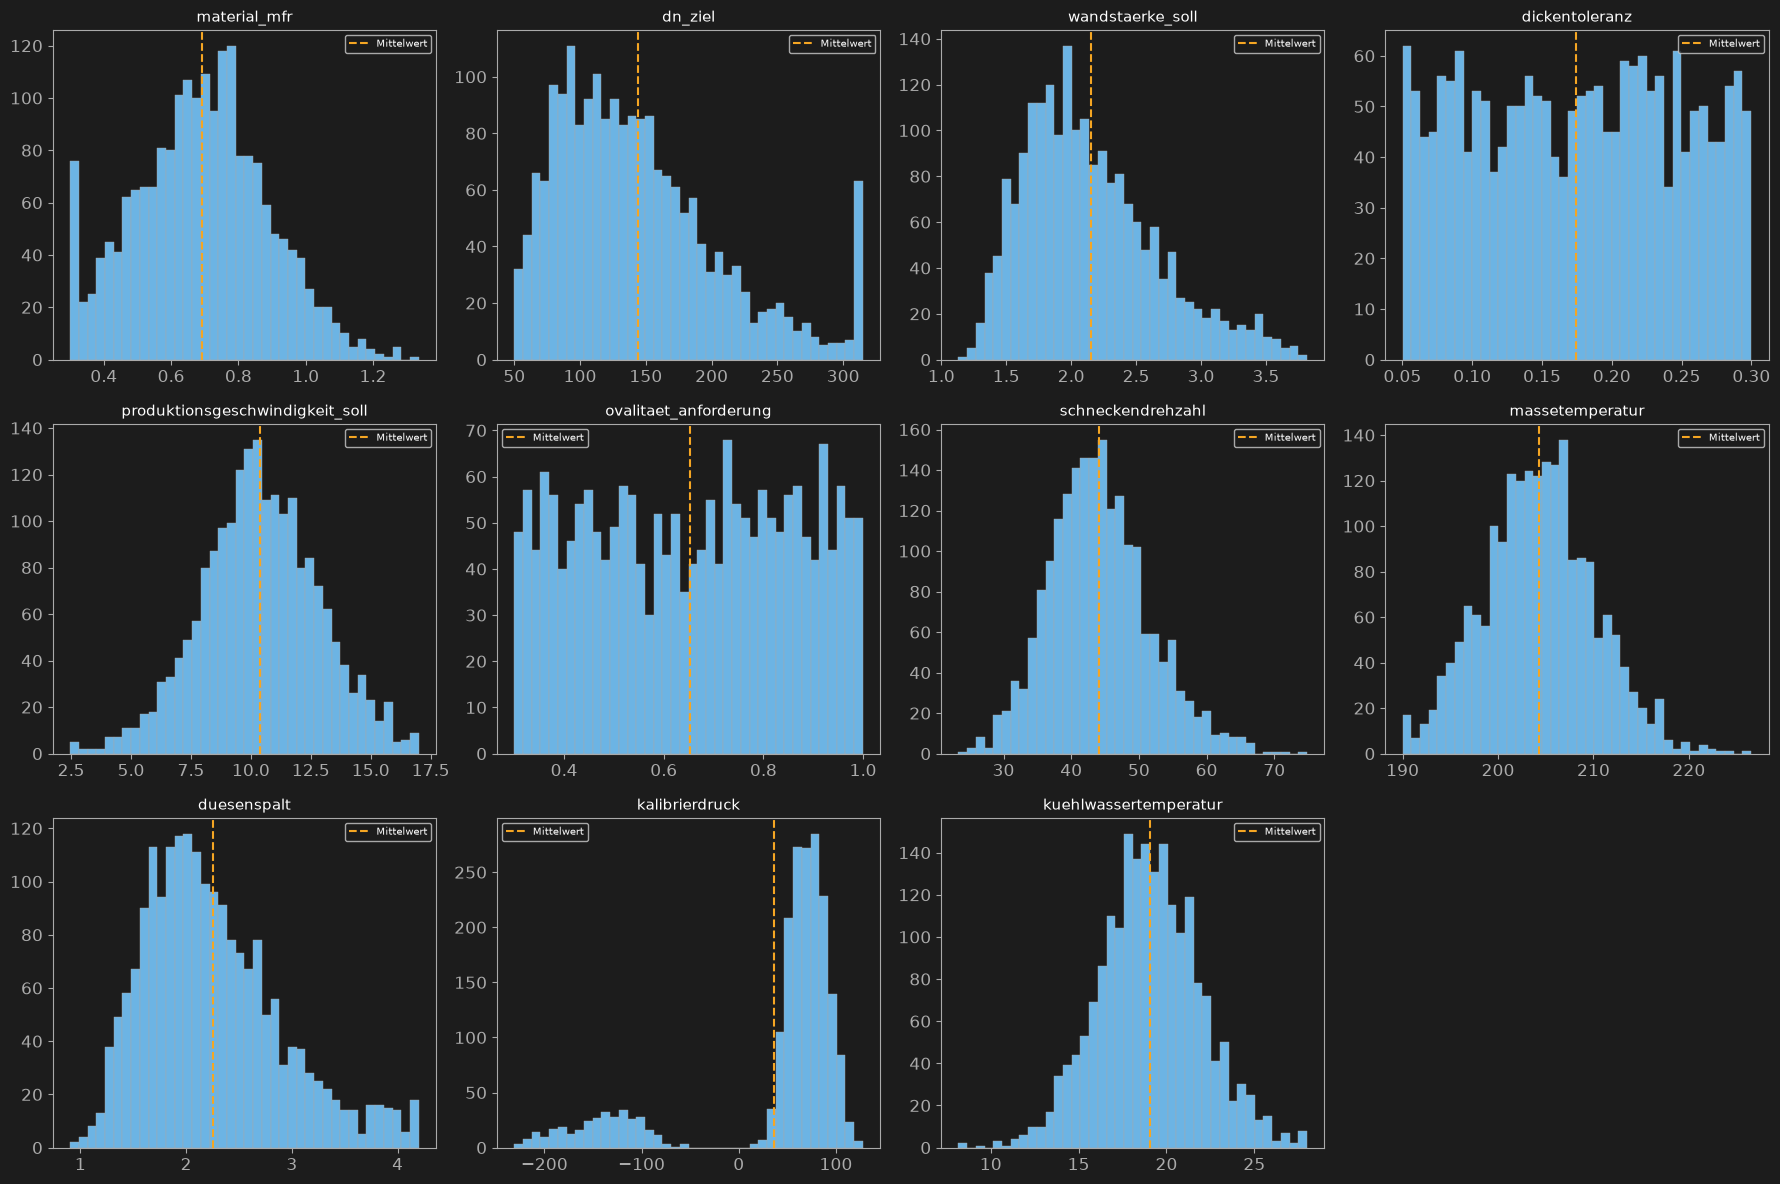

In [7]:
# =============================================================================
# Zelle 03 – Verteilungs-Histogramme aller numerischen X_B/Y_B-Merkmale
# =============================================================================
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for ax, col in zip(axes, numerische_merkmale):
    ax.hist(df_b[col], bins=40, color=COLOR_BLUE, edgecolor=COLOR_TEXT_MUTED, linewidth=0.3)
    ax.axvline(df_b[col].mean(), color=COLOR_GOLD, linestyle="--", linewidth=1.5, label="Mittelwert")
    ax.set_title(col, fontsize=11)
    ax.legend(fontsize=7)

# Leere Subplots ausblenden (12 Slots, 11 Merkmale)
for ax in axes[len(numerische_merkmale):]:
    ax.axis("off")

plt.tight_layout()
save_figure(fig, "../reports/figures/09_verteilungen_model_b.png")
plt.show()

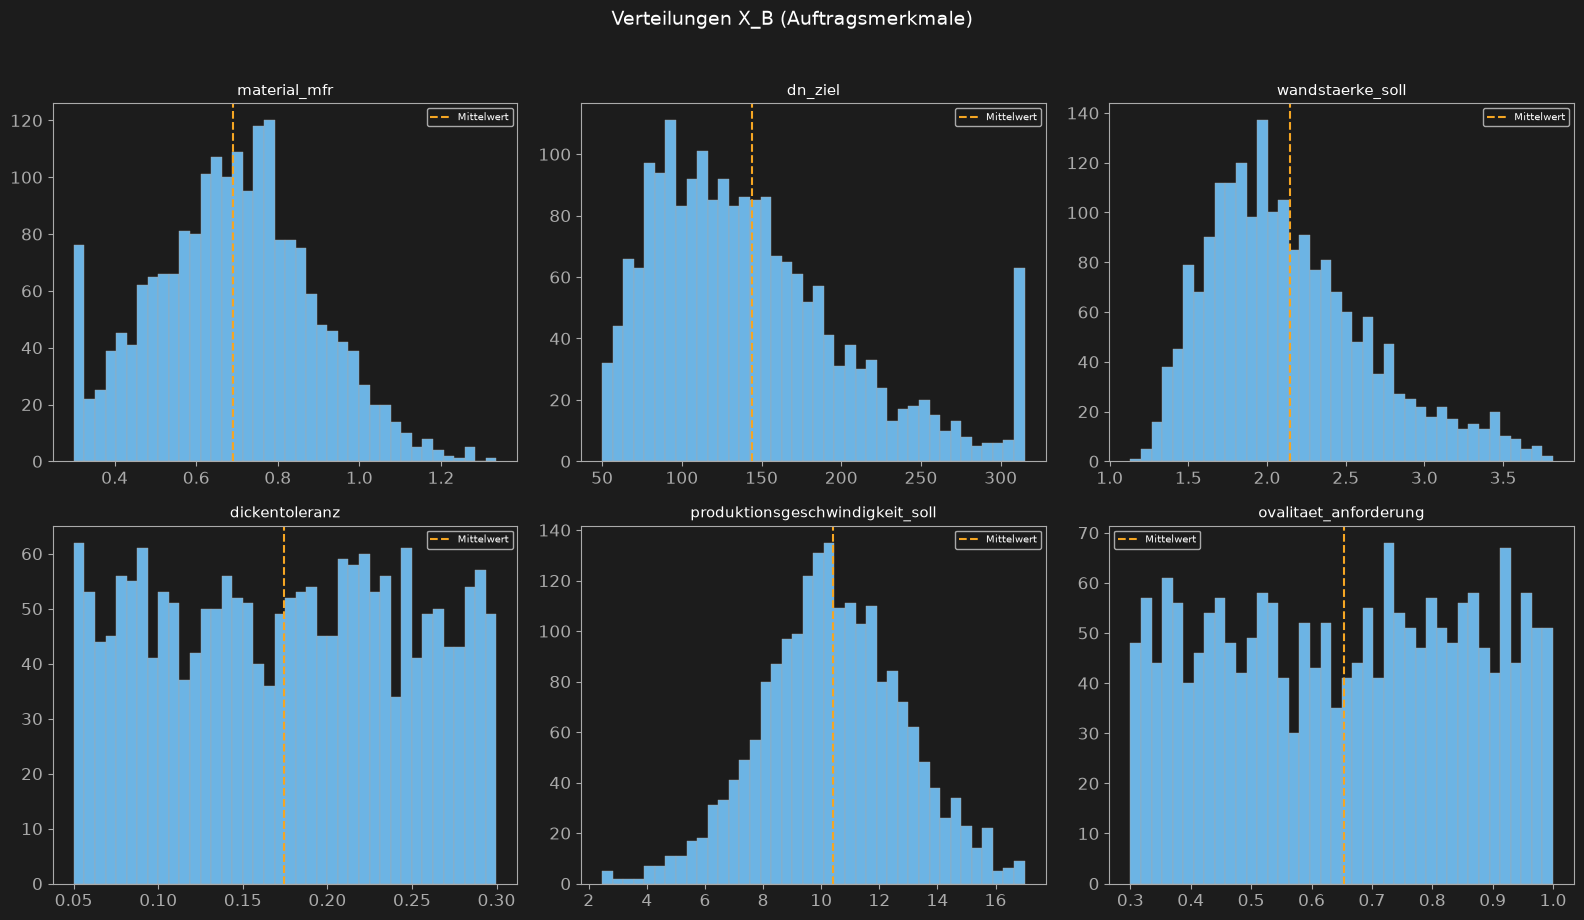

In [8]:
# =============================================================================
# Zelle 03a – Verteilungs-Histogramme X_B (Auftragsmerkmale)
# =============================================================================
x_b_numerisch = [c for c in X_B_MERKMALE if c != "wandtyp"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, col in zip(axes, x_b_numerisch):
    ax.hist(df_b[col], bins=40, color=COLOR_BLUE, edgecolor=COLOR_TEXT_MUTED, linewidth=0.3)
    ax.axvline(df_b[col].mean(), color=COLOR_GOLD, linestyle="--", linewidth=1.5, label="Mittelwert")
    ax.set_title(col, fontsize=11)
    ax.legend(fontsize=7)

for ax in axes[len(x_b_numerisch):]:
    ax.axis("off")

fig.suptitle("Verteilungen X_B (Auftragsmerkmale)", fontsize=14, y=1.02)
plt.tight_layout()
save_figure(fig, "../reports/figures/09_verteilungen_x_b.png")
plt.show()

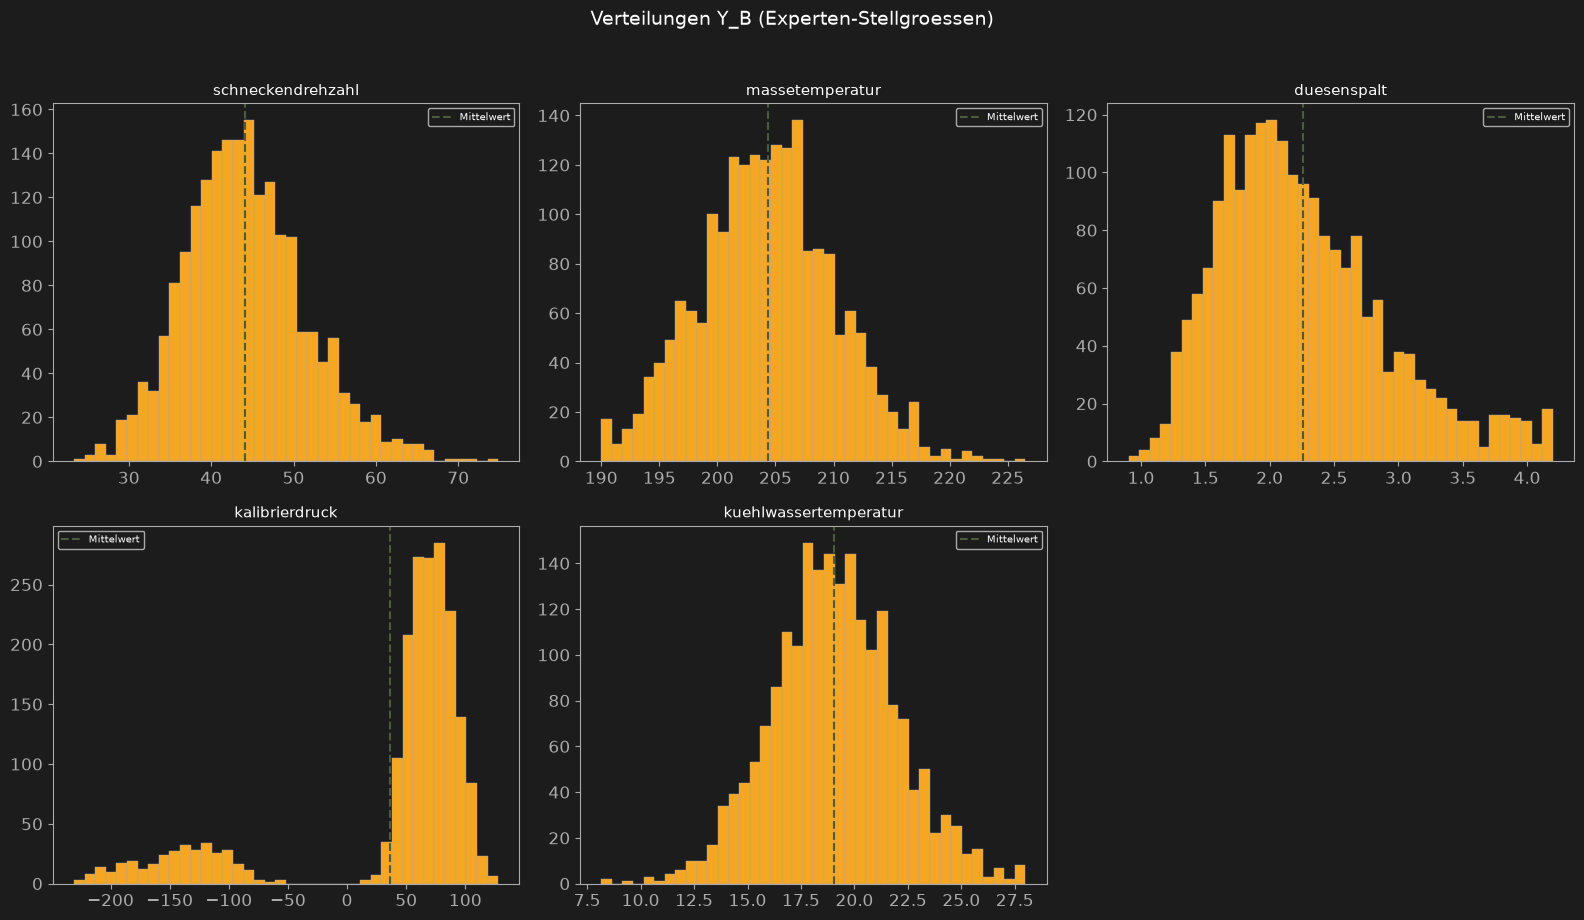

In [9]:
# =============================================================================
# Zelle 03b – Verteilungs-Histogramme Y_B (Experten-Stellgroessen)
# =============================================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, col in zip(axes, Y_B_MERKMALE):
    ax.hist(df_b[col], bins=40, color=COLOR_GOLD, edgecolor=COLOR_TEXT_MUTED, linewidth=0.3)
    ax.axvline(df_b[col].mean(), color=COLOR_GREEN, linestyle="--", linewidth=1.5, label="Mittelwert")
    ax.set_title(col, fontsize=11)
    ax.legend(fontsize=7)

for ax in axes[len(Y_B_MERKMALE):]:
    ax.axis("off")

fig.suptitle("Verteilungen Y_B (Experten-Stellgroessen)", fontsize=14, y=1.02)
plt.tight_layout()
save_figure(fig, "../reports/figures/09_verteilungen_y_b.png")
plt.show()